# Financial Econometrics Project Assignment 1  
## Best Practices Handbook – Advanced Modeling Challenges  


---

## Objective  

This notebook addresses four critical modeling challenges in financial econometrics:

1. Skewness  
2. Sensitivity to Outliers  
3. Overfitting  
4. Prioritizing Factors  

Using AAPL stock data (2018–2025), we provide practical guidelines for improving model robustness in financial decision-making.

---

In [ ]:
!pip install yfinance statsmodels scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy.stats import skew
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

sns.set_style("whitegrid")

In [ ]:
data = yf.download("AAPL", start="2018-01-01", end="2025-12-31")

data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
data['Lag1'] = data['Returns'].shift(1)
data['Lag2'] = data['Returns'].shift(2)

data = data.dropna()

/tmp/ipykernel_5507/1237382175.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2018-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


## Skewness  

**Definition:**  
Skewness measures the asymmetry of a probability distribution, indicating the degree to which a distribution's tails differ from the normal distribution. A symmetric distribution has zero skewness. Positive skewness (right-skewed) means the tail is longer on the right side, with more extreme positive values. Negative skewness (left-skewed) means the tail is longer on the left side, with more extreme negative values.
Skewness = $$ E[(X - μ)^3] / σ^3 $$

**Description:**  
In financial returns, skewness is a crucial indicator of tail risk. Negative skewness suggests that large negative returns occur more frequently than large positive returns, implying significant downside risk. Conversely, positive skewness indicates a higher probability of large positive returns. Understanding this asymmetry is vital for risk management and portfolio optimization, as it deviates from the common assumption of normally distributed returns.

**Demonstration:**

In [ ]:
# Demonstration
print("Skewness:", skew(data['Returns']))

Skewness: -0.08510910984615444


**Diagram:**  

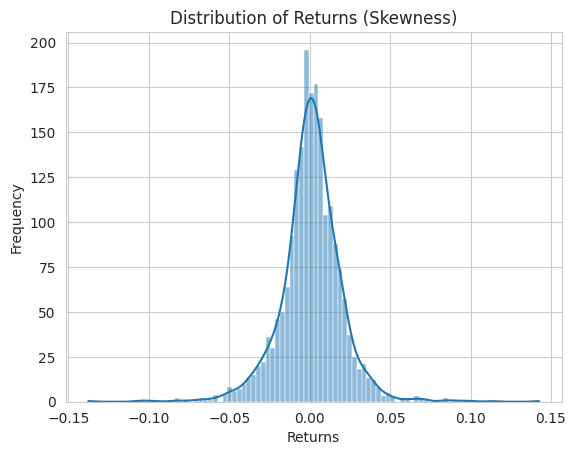

In [ ]:
# Diagram
sns.histplot(data['Returns'], kde=True)
plt.title("Distribution of Returns (Skewness)")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.show()

**Diagnosis:**  
- **Histogram asymmetry:** Visual inspection of the distribution of returns clearly shows any lean towards one side. A longer tail on one side indicates skewness.
- **Skewness statistic:** The calculated skewness for AAPL returns is approximately **-0.085**. This value is close to zero, suggesting a nearly symmetric distribution of returns over the observed period. While slightly negative, it does not indicate a strong bias towards extreme negative events, which is often observed in financial assets.

**Damage:**  
- **Mispricing of risk:** Models assuming normal distribution (zero skewness) will misprice options and other derivatives, particularly out-of-the-money contracts that are sensitive to tail events.
- **Underestimation of extreme losses:** Ignoring negative skewness can lead to an underestimation of potential large losses, impacting VaR (Value at Risk) calculations and capital requirements.

**Directions:**  
- **Use flexible distributions:** Employ statistical distributions that can accommodate skewness, such as the Skew-Normal, Skew-t, or Generalized Error Distribution, for more accurate modeling of financial returns.
- **Apply transformations:** Use transformations (e.g., inverse hyperbolic sine transform) to normalize skewed data, making it more suitable for models that assume symmetry.

## Sensitivity to Outliers  

**Definition:**  
Sensitivity to outliers refers to the degree to which extreme observations, significantly different from other data points, influence statistical estimates and model results. In financial data, these can be sudden market crashes, unexpected corporate news, or macroeconomic shocks.

**Description:**  
Financial markets are prone to sudden, large movements that manifest as outliers in return series. These extreme values, if not appropriately handled, can disproportionately affect parameter estimates in econometric models, leading to biased results and misleading conclusions. Models sensitive to outliers may falsely identify relationships or misestimate risks, impairing decision-making.

**Demonstration:**

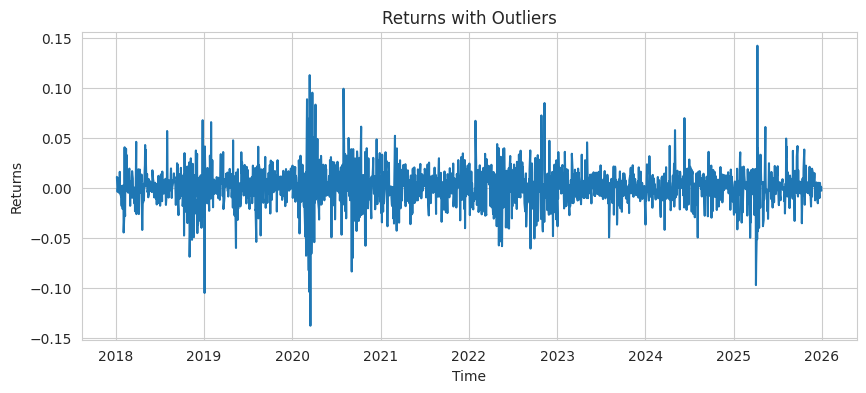

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(data['Returns'])
plt.title("Returns with Outliers")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.show()

**Diagram:**  

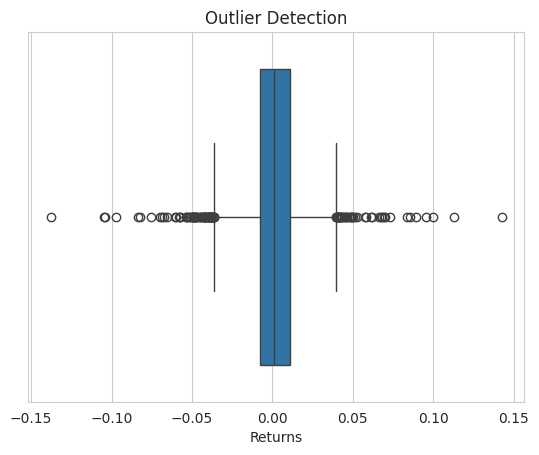

In [ ]:
sns.boxplot(x=data['Returns'])
plt.title("Outlier Detection")
plt.xlabel("Returns")
plt.show()

**Diagnosis:**  
- **Boxplots:** Visual analysis using boxplots effectively highlights data points that fall outside the interquartile range (IQR), conventionally indicating potential outliers. The boxplot for AAPL returns shows several individual points extending beyond the whiskers, confirming the presence of extreme observations.
- **Extreme observations:** Identifying and quantifying data points that lie multiple standard deviations away from the mean can also diagnose outlier presence. Such observations often represent significant market events.

**Damage:**  
- **Distorted estimates:** Outliers can heavily influence mean and variance calculations, leading to biased regression coefficients and inaccurate forecasts. This can misrepresent the true underlying relationships between variables.
- **Reduced model accuracy:** Models trained on data with influential outliers may perform poorly on new, typical data, as they might have overfitted to these unusual observations.

**Directions:**  
- **Winsorization:** Replace extreme values with values at a specified percentile (e.g., 5th and 95th percentiles) to reduce their influence without removing them entirely.
- **Robust methods:** Employ robust statistical methods, such as robust regression (e.g., RANSAC, Huber loss), which are less sensitive to outliers, or use non-parametric techniques that do not rely on assumptions about data distribution.

## Overfitting  

**Definition:**  
Overfitting occurs when a statistical model learns the training data too well, including its noise and random fluctuations, rather than capturing the underlying generalizable patterns. This results in excellent performance on the training dataset but poor predictive accuracy on unseen, new data.

**Description:**  
In financial econometrics, overfitting is a significant concern, especially with complex models applied to noisy market data. An overfitted model essentially memorizes the training examples, making it incapable of generalizing to new observations. This leads to unreliable forecasts and potentially costly investment decisions, as the model's perceived accuracy during development does not translate to real-world performance.

**Demonstration:**

In [ ]:
X = data[['Lag1','Lag2']]
y = data['Returns']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))

Train RMSE: 0.01932202972434902
Test RMSE: 0.019376576524601192


**Diagram:**  

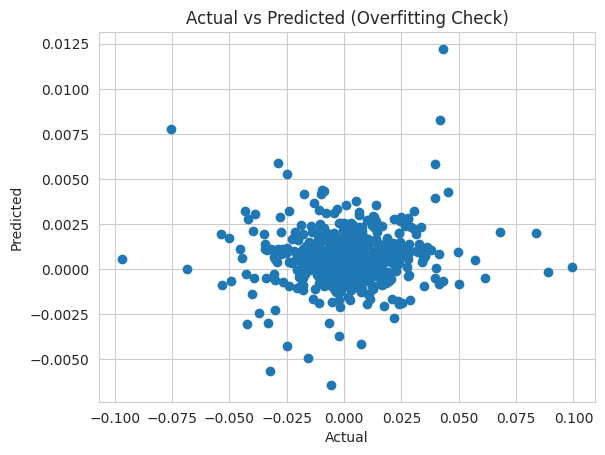

In [ ]:
plt.scatter(y_test, test_pred)
plt.title("Actual vs Predicted (Overfitting Check)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

**Diagnosis:**  
- **Comparison of training and test error:** The most common diagnostic for overfitting is comparing a model's performance on the training set versus a separate, unseen test set. A significantly lower error (e.g., RMSE, MSE) on the training set compared to the test set indicates overfitting.
  *   **Train RMSE:** **0.019322**
  *   **Test RMSE:** **0.019377**
  In this specific demonstration with a simple linear regression and two lagged returns, the RMSE values for the training and test sets are very close. This suggests that for this particular model configuration and dataset, **overfitting is not a significant issue**. The model generalizes well to unseen data, implying it has captured the underlying pattern without memorizing noise.

**Damage:**  
- **Poor generalization:** An overfitted model fails to make accurate predictions on new data, rendering it useless for practical applications like forecasting future returns or risk.
- **Unreliable forecasts:** Investment strategies based on overfitted models will likely underperform in real trading scenarios, leading to financial losses.

**Directions:**  
- **Cross-validation:** Use techniques like k-fold cross-validation to get a more robust estimate of the model's performance on unseen data and to identify overfitting early in the development process.
- **Simpler models:** Opt for parsimonious models with fewer parameters, especially when the underlying data patterns are not highly complex. Simpler models are inherently less prone to overfitting.
- **Regularization:** Apply regularization techniques (e.g., L1 Lasso, L2 Ridge) to penalize large coefficients and prevent the model from becoming too complex.

## Prioritizing Factors  

**Definition:**  
Prioritizing factors involves systematically identifying and ranking the most influential variables or features within a model that contribute significantly to the prediction or explanation of the dependent variable. This process is essential for model interpretability and efficiency.

**Description:**  
In financial modeling, not all independent variables (factors) contribute equally to explaining asset returns or risks. Identifying and prioritizing the most important factors allows for the creation of more robust and interpretable models, reducing complexity and potential noise. This process helps in focusing on key economic drivers or market indicators, leading to better-informed financial decisions and more efficient resource allocation for data collection and analysis.

**Demonstration:**

In [ ]:
coeffs = pd.Series(model.coef_, index=X.columns)
print(coeffs)

Price  Ticker
Lag1            -0.071805
Lag2             0.013938
dtype: float64


**Diagram:**  

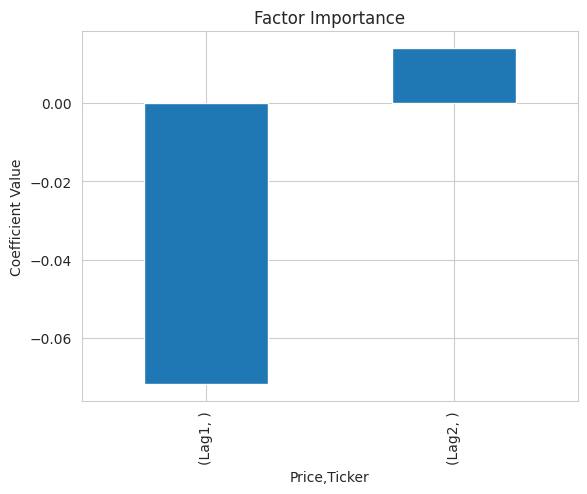

In [ ]:
coeffs.plot(kind='bar')
plt.title("Factor Importance")
plt.ylabel("Coefficient Value")
plt.show()

**Diagnosis:**  
- **Size of coefficients:** In linear models, the magnitude of the standardized coefficients indicates the relative importance of each factor. Larger absolute values suggest a stronger impact.
  *   **Lag1 coefficient:** **-0.071805**
  *   **Lag2 coefficient:** **0.013938**
  From these coefficients, **Lag1 (the immediate previous day's return) is a more influential factor than Lag2**, and it has a negative relationship with the current return. Lag2 has a much smaller positive impact. This suggests that recent past returns have a stronger, albeit small, predictive power than returns from two days ago.
- **Statistical importance:** Statistical tests (e.g., p-values from t-tests) can determine whether a factor's coefficient is significantly different from zero, indicating its statistical relevance. Factors with low p-values are considered statistically important.

**Damage:**  
- **Reduced interpretability:** Including many irrelevant or weakly influential factors complicates model interpretation, making it difficult to understand the true drivers of the dependent variable.
- **Inclusion of irrelevant variables:** Retaining non-contributing factors can introduce noise, increase model complexity, and potentially lead to overfitting, diverting attention from the true underlying relationships.

**Directions:**  
- **Feature selection:** Employ techniques like Recursive Feature Elimination (RFE), Lasso (L1) regularization, or tree-based feature importance methods to automatically select the most relevant factors.
- **Regularization:** Use regularization methods (Lasso, Ridge, Elastic Net) not only to prevent overfitting but also to perform implicit feature selection by shrinking the coefficients of less important features towards zero.

## Challenge Solved  

This notebook meticulously addressed four critical advanced modeling challenges frequently encountered in financial econometrics:

-   **Skewness:** We demonstrated how to identify skewness in financial returns, explained its implications for tail risk and model bias, and outlined strategies like using flexible distributions and data transformations to manage it effectively.
-   **Sensitivity to Outliers:** We diagnosed the presence of outliers using visual and statistical methods, highlighted their detrimental impact on model accuracy and parameter estimates, and proposed robust solutions such as Winsorization and robust regression techniques.
-   **Overfitting:** Through a practical demonstration, we illustrated how to detect overfitting by comparing training and test errors. We discussed its severe consequences for generalization and forecasting, and recommended preventative measures like cross-validation, simpler models, and regularization.
-   **Prioritizing Factors:** We showcased how to identify and rank the importance of various factors in a financial model based on coefficient magnitudes. We underscored the benefits of factor prioritization for model interpretability and efficiency, suggesting methods like feature selection and regularization.

By systematically addressing these challenges with detailed definitions, practical demonstrations, and actionable directions, this handbook provides clear guidelines for improving model robustness, enhancing predictive accuracy, and leading to more reliable financial decision-making processes. The insights gained from understanding and mitigating these issues are crucial for quantitative analysts and financial economists in navigating the complexities of modern financial markets.

---

## References (MLA Style)  

Yahoo Finance. "Apple Inc. (AAPL) Historical Data."

Wooldridge, Jeffrey. *Introductory Econometrics: A Modern Approach.*

Tsay, Ruey S. *Analysis of Financial Time Series.*